# MATH70113 Simulation Methods for Finance – Group Assignment
## Part 1: Pathwise Sensitivities for a Down-and-Out Barrier Option

### Problem setup
We consider the discounted payoff
$$V = \mathbb{E}\left[ e^{-rT} (S_T - K)^+ \mathbf{1}_{\min_{t\in[0,T]} S_t > B} \right]$$
with $S$ following GBM: $dS_t = r S_t \, dt + \sigma S_t \, dW_t$, and parameters:
- $r = 0.05$, $\sigma = 0.5$, $T = 1$, $S_0 = 100$, $K = 110$, $B = 90$.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Parameters
r = 0.05
sigma = 0.5
T = 1.0
S0 = 100.0
K = 110.0
B = 90.0

### 1. GBM simulation and Brownian bridge barrier crossing
We simulate $S$ exactly (log-normal). For **O(h) weak convergence** we use the **barrier crossing technique** (Glasserman §6.4): in each step $[t_i, t_{i+1}]$ we use the Brownian bridge to compute the probability that $S_t$ stayed above $B$. The one-step survival probability is
$$P(\min_{[t_i,t_{i+1}]} S_t > B \mid S_{t_i}, S_{t_{i+1}}) = 1 - \exp\left( -\frac{2}{\sigma^2 h} (\log S_{t_i} - \log B)(\log S_{t_{i+1}} - \log B) \right)$$
when $\min(S_{t_i}, S_{t_{i+1}}) > B$, and 0 otherwise. The path survival weight is the product of these over all steps.

In [7]:
def one_step_survival_prob(log_S_i, log_S_ip1, log_B, sigma_sq, h):
    """P(min S_t > B in [t_i, t_{i+1}] | S_i, S_{i+1}) using Brownian bridge (Glasserman 6.4)."""
    if min(log_S_i, log_S_ip1) <= log_B:
        return 0.0
    # P(crossed) = exp(-2 (log S_i - log B)(log S_{i+1} - log B) / (sigma^2 h))
    p_crossed = np.exp(-2.0 * (log_S_i - log_B) * (log_S_ip1 - log_B) / (sigma_sq * h))
    return 1.0 - p_crossed


def simulate_gbm_paths(S0, r, sigma, T, N_steps, N_paths, seed=None):
    """Exact GBM: S_t = S0 * exp((r - sigma^2/2)*t + sigma*W_t). Returns S (N_paths, N_steps+1) and W (N_paths, N_steps+1)."""
    if seed is not None:
        np.random.seed(seed)
    h = T / N_steps
    # Increments dW
    dW = np.random.standard_normal((N_paths, N_steps)) * np.sqrt(h)
    W = np.zeros((N_paths, N_steps + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    drift = (r - 0.5 * sigma ** 2) * T
    # S at each step: S_i = S0 * exp((r - sigma^2/2)*t_i + sigma*W_{t_i})
    t = np.linspace(0, T, N_steps + 1)
    S = S0 * np.exp((r - 0.5 * sigma ** 2) * t + sigma * W)
    return S, W, h


def barrier_survival_product(S_path, B, sigma, h):
    """Product of one-step survival probs (Brownian bridge) for one path. S_path shape (N_steps+1,)."""
    log_S = np.log(S_path)
    log_B = np.log(B)
    sigma_sq = sigma ** 2
    prod = 1.0
    for i in range(len(S_path) - 1):
        prod *= one_step_survival_prob(log_S[i], log_S[i + 1], log_B, sigma_sq, h)
    return prod


def barrier_survival_product_batch(S, B, sigma, h):
    """Vectorised: survival product for all paths. S shape (N_paths, N_steps+1)."""
    log_S = np.log(S)
    log_B = np.log(B)
    sigma_sq = sigma ** 2
    # P(crossed) = exp(-2 (log S_i - log B)(log S_{i+1} - log B) / (sigma^2 h))
    log_S_i = log_S[:, :-1]
    log_S_ip1 = log_S[:, 1:]
    p_crossed = np.exp(-2.0 * (log_S_i - log_B) * (log_S_ip1 - log_B) / (sigma_sq * h))
    p_crossed[np.minimum(log_S_i, log_S_ip1) <= log_B] = 1.0  # already at or below B
    survival = np.prod(1.0 - p_crossed, axis=1)
    return survival

### 2. Pathwise Delta and Vega
For paths that survive and $S_T > K$:
- **Delta:** $\frac{\partial S_T}{\partial S_0} = \frac{S_T}{S_0}$, so pathwise Delta = $e^{-rT} \frac{S_T}{S_0} \mathbf{1}_{S_T>K} \times \text{survival}$ plus the derivative of the survival product w.r.t. $S_0$ (via chain rule through each $S_i$).
- **Vega:** $\frac{\partial S_T}{\partial \sigma} = S_T (W_T - \sigma T)$, so pathwise Vega = $e^{-rT} S_T (W_T - \sigma T) \mathbf{1}_{S_T>K} \times \text{survival}$ plus the derivative of the survival product w.r.t. $\sigma$.
We include the derivative of the survival product for correctness; the one-step probability $p_i = \exp(\frac{2}{\sigma^2 h}(\log B - \min(\log S_i, \log S_{i+1}))^2)$ is differentiable in $S_i$, $S_{i+1}$ and $\sigma$.

In [ ]:
def pathwise_delta_vega(S, W, h, S0, r, sigma, T, K, B):
    """
    Pathwise Delta and Vega for down-and-out call with barrier crossing (survival product).
    S, W: (N_paths, N_steps+1). Returns (delta_samples, vega_samples, payoff_samples).
    """
    N_paths, N_steps_plus_1 = S.shape
    N_steps = N_steps_plus_1 - 1
    log_S = np.log(S)
    log_B = np.log(B)
    sigma_sq = sigma ** 2
    log_S_i = log_S[:, :-1]
    log_S_ip1 = log_S[:, 1:]
    
    # One-step survival: 1 - p_crossed (Brownian bridge formula)
    p_crossed = np.exp(-2.0 * (log_S_i - log_B) * (log_S_ip1 - log_B) / (sigma_sq * h))
    p_crossed[np.minimum(log_S_i, log_S_ip1) <= log_B] = 1.0
    one_minus_p = 1.0 - p_crossed  # (N_paths, N_steps)
    survival = np.prod(one_minus_p, axis=1)  # (N_paths,)
    
    ST = S[:, -1]
    WT = W[:, -1]
    payoff_disc = np.exp(-r * T) * np.maximum(ST - K, 0.0)
    payoff_weighted = payoff_disc * survival
    
    # Pathwise Delta: e^{-rT} (S_T/S_0) * 1_{S_T>K} * survival + e^{-rT}(S_T-K)+ * d(survival)/dS_0
    # d(survival)/dS_0: survival = prod_i (1-p_i). d(1-p_i)/dS_0 = - dp_i/dS_0.
    # p_i = exp(2*(log B - m_i)^2/(sigma^2 h)), m_i = min(log S_i, log S_{i+1}). dm_i/dS_0 = 1/S_0 (since S_i = S0 * ..., so d log S_i/dS_0 = 1/S_0).
    # p_i = exp(-2 (log S_i - log B)(log S_{i+1} - log B)/(sigma^2 h)). d(log S)/dS_0 = 1/S_0.
    # d(1-p_i)/dS_0 = p_i * 2((log S_i - log B)+(log S_{i+1} - log B))/(sigma^2 h S_0).
    delta_pathwise = np.exp(-r * T) * (ST / S0) * (ST > K).astype(float) * survival
    
    term_dS0 = np.zeros(N_paths)
    for i in range(N_steps):
        surv_no_i = np.prod(one_minus_p[:, np.arange(N_steps) != i], axis=1)
        a_i = log_S_i[:, i] - log_B
        b_i = log_S_ip1[:, i] - log_B
        p_i = p_crossed[:, i]
        term_dS0 += surv_no_i * p_i * 2.0 * (a_i + b_i) / (sigma_sq * h)
    d_survival_dS0 = term_dS0 / S0
    # Only add correction where survival > 0 (otherwise pathwise derivative of 0 is 0)
    mask = survival > 0
    delta_pathwise += np.exp(-r * T) * np.maximum(ST - K, 0.0) * d_survival_dS0 * mask
    
    # Pathwise Vega: e^{-rT} S_T (W_T - sigma*T) * 1_{S_T>K} * survival + payoff * d(survival)/d_sigma
    vega_pathwise = np.exp(-r * T) * ST * (WT - sigma * T) * (ST > K).astype(float) * survival
    # d(1-p_i)/d_sigma = - dp_i/d_sigma = p_i * 4*(log S_i - log B)(log S_{i+1} - log B)/(sigma^3 h)
    term_dsigma = np.zeros(N_paths)
    for i in range(N_steps):
        surv_no_i = np.prod(one_minus_p[:, np.arange(N_steps) != i], axis=1)
        a_i = log_S_i[:, i] - log_B
        b_i = log_S_ip1[:, i] - log_B
        p_i = p_crossed[:, i]
        term_dsigma += surv_no_i * p_i * 4.0 * a_i * b_i / (sigma ** 3 * h)
    d_survival_dsigma = term_dsigma
    vega_pathwise += np.exp(-r * T) * np.maximum(ST - K, 0.0) * d_survival_dsigma * mask
    
    return delta_pathwise, vega_pathwise, payoff_weighted

In [9]:
# Simulation parameters
N_paths = 200_000
N_steps = 100

S, W, h = simulate_gbm_paths(S0, r, sigma, T, N_steps, N_paths, seed=42)
delta_samples, vega_samples, payoff_samples = pathwise_delta_vega(S, W, h, S0, r, sigma, T, K, B)

V_hat = np.mean(payoff_samples)
delta_hat = np.mean(delta_samples)
vega_hat = np.mean(vega_samples)

print(f"Option value (with barrier crossing): V_hat = {V_hat:.6f}")
print(f"Pathwise Delta = {delta_hat:.6f}")
print(f"Pathwise Vega  = {vega_hat:.6f}")
print(f"Std(V_hat) = {np.std(payoff_samples)/np.sqrt(N_paths):.6f}")
print(f"Std(Delta_hat) = {np.std(delta_samples)/np.sqrt(N_paths):.6f}")
print(f"Std(Vega_hat) = {np.std(vega_samples)/np.sqrt(N_paths):.6f}")

Option value (with barrier crossing): V_hat = 8.555193
Pathwise Delta = 0.865619
Pathwise Vega  = 25.942972
Std(V_hat) = 0.066652
Std(Delta_hat) = 0.009331
Std(Vega_hat) = 0.225414


### 3. Weak convergence in step size $h$
We check that the bias is **O(h)** by varying $N_{\text{steps}}$ (hence $h = T/N_{\text{steps}}$) and comparing to a fine reference.

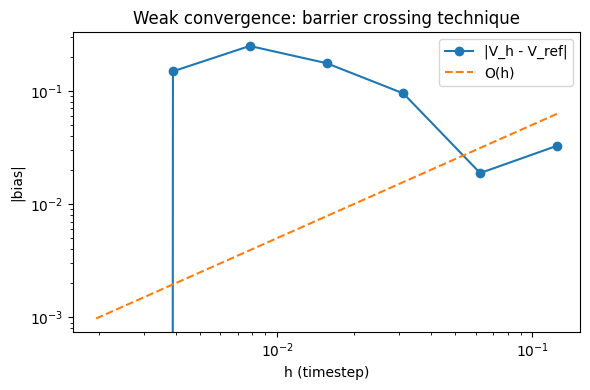

In [10]:
N_paths_conv = 100_000
steps_list = [8, 16, 32, 64, 128, 256, 512]
values = []
for N_steps in steps_list:
    S, W, h = simulate_gbm_paths(S0, r, sigma, T, N_steps, N_paths_conv, seed=43)
    _, _, pay = pathwise_delta_vega(S, W, h, S0, r, sigma, T, K, B)
    values.append(np.mean(pay))

values = np.array(values)
h_list = T / np.array(steps_list)
ref = values[-1]  # finest as reference
err = np.abs(values - ref)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.loglog(h_list, err, 'o-', label='|V_h - V_ref|')
ax.loglog(h_list, 0.5 * h_list, '--', label='O(h)')
ax.set_xlabel('h (timestep)')
ax.set_ylabel('|bias|')
ax.legend()
ax.set_title('Weak convergence: barrier crossing technique')
plt.tight_layout()
plt.show()

### 4. Visualisation: distribution of pathwise estimators
Histograms of pathwise Delta and Vega samples (only for paths that contribute, i.e. survival > 0 and $S_T > K$ in the support of the estimator).

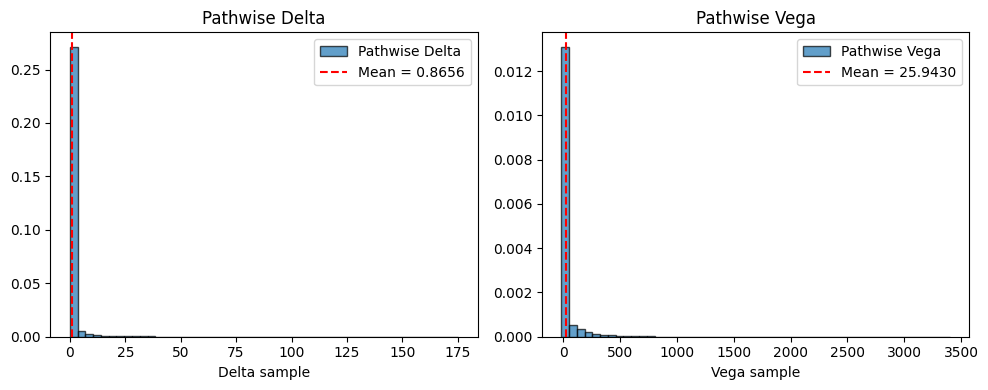

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(delta_samples, bins=50, density=True, alpha=0.7, edgecolor='k', label='Pathwise Delta')
axes[0].axvline(delta_hat, color='red', linestyle='--', label=f'Mean = {delta_hat:.4f}')
axes[0].set_xlabel('Delta sample')
axes[0].legend()
axes[0].set_title('Pathwise Delta')

axes[1].hist(vega_samples, bins=50, density=True, alpha=0.7, edgecolor='k', label='Pathwise Vega')
axes[1].axvline(vega_hat, color='red', linestyle='--', label=f'Mean = {vega_hat:.4f}')
axes[1].set_xlabel('Vega sample')
axes[1].legend()
axes[1].set_title('Pathwise Vega')
plt.tight_layout()
plt.show()

### 5. Finite-difference check (optional)
Validate pathwise Delta and Vega by comparing with finite-difference estimates: $\Delta \approx (V(S_0+\varepsilon) - V(S_0-\varepsilon))/(2\varepsilon)$ and similarly for Vega.

In [ ]:
def option_value_mc(S0, r, sigma, T, K, B, N_steps, N_paths, seed=None):
    S, W, h = simulate_gbm_paths(S0, r, sigma, T, N_steps, N_paths, seed=seed)
    _, _, pay = pathwise_delta_vega(S, W, h, S0, r, sigma, T, K, B)
    return np.mean(pay)

eps_S0 = 1.0
eps_sigma = 0.01
V_center = option_value_mc(S0, r, sigma, T, K, B, N_steps, N_paths, seed=44)
V_plus_S0 = option_value_mc(S0 + eps_S0, r, sigma, T, K, B, N_steps, N_paths, seed=44)
V_minus_S0 = option_value_mc(S0 - eps_S0, r, sigma, T, K, B, N_steps, N_paths, seed=44)
delta_fd = (V_plus_S0 - V_minus_S0) / (2 * eps_S0)

V_plus_sigma = option_value_mc(S0, r, sigma + eps_sigma, T, K, B, N_steps, N_paths, seed=44)
V_minus_sigma = option_value_mc(S0, r, sigma - eps_sigma, T, K, B, N_steps, N_paths, seed=44)
vega_fd = (V_plus_sigma - V_minus_sigma) / (2 * eps_sigma)

print('Finite-difference vs pathwise:')
print(f'  Delta: FD = {delta_fd:.6f}, pathwise = {delta_hat:.6f}')
print(f'  Vega:  FD = {vega_fd:.6f}, pathwise = {vega_hat:.6f}')